# Final Project: Customer Churn Prediction Using Machine Learning

## Introduction

Customer churn is one of the most important business problems in the telecommunications industry. Churn happens when a customer stops using a company's services and moves to another provider. For telecom companies, losing customers can reduce revenue and increase the cost of gaining new customers.

The goal of this project is to build a machine learning model that can predict whether a customer is likely to churn based on customer information, service usage, contract type, payment method, and monthly charges.

In this project, I will use the IBM Telco Customer Churn dataset. The dataset contains customer demographics, account information, subscribed services, and whether the customer churned or not. This is a classification problem because the target variable has two possible outcomes: Yes or No.

This project will include data loading, data exploration, data cleaning, preprocessing, visualization, model training, model evaluation, hyperparameter tuning, and a simple interactive deployment inside Google Colab.

## Step 1: Import Libraries and Load the Dataset

In this step, I will import the required Python libraries and load the IBM Telco Customer Churn dataset directly from an online CSV link. This allows the notebook to run easily without manually uploading the dataset.

In [118]:
# Import basic libraries for data analysis
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import warning library to ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

# Dataset URL from IBM GitHub repository
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(url)

# Display the first five rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Observation

The dataset was loaded successfully without any errors. By displaying the first five rows, I confirmed that the data contains customer demographic information, account details, subscribed services, and the target variable **Churn**. The dataset appears to be suitable for further exploration, preprocessing, and machine learning model development.

# Step 2: Understanding the Dataset

## Objective

Before preprocessing the data, it is important to understand the dataset's structure. In this step, I will examine the size of the dataset, column names, data types, and basic statistical information. This helps identify potential issues such as incorrect data types or missing values before building the machine learning model.

## Why is this step important?

Understanding the dataset is an essential first step in any machine learning project. It provides insights into the available features, the target variable, and the overall quality of the data, allowing appropriate preprocessing decisions to be made later.

In [119]:
# Display the number of rows and columns in the dataset
print("Dataset Shape:", df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [120]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [121]:
# Display summary statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [122]:
# Display summary statistics for all columns, including categorical columns
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## Observation

The dataset contains customer demographic information, account details, and subscribed services. It includes both numerical and categorical features, making it suitable for a classification task. The summary statistics provide an initial understanding of the data distribution, while the dataset structure helps identify which columns may require preprocessing before model training.

# Step 3: Exploratory Data Analysis (EDA)

## Objective

In this step, I will explore the dataset visually to better understand the distribution of customers and identify possible patterns related to customer churn. Data visualization helps reveal trends that may not be obvious from raw tables alone.

## Why is this step important?

Exploratory Data Analysis (EDA) is an essential step before building a machine learning model. It helps identify patterns, relationships, and potential factors that influence the target variable (Churn). These insights can also guide feature selection and model improvement.

### 3.1 Distribution of Customer Churn

Before analyzing the relationships between features and the target variable, it is important to understand the distribution of customer churn. A count plot is the most appropriate visualization because the target variable (Churn) is categorical with only two possible values (Yes and No).

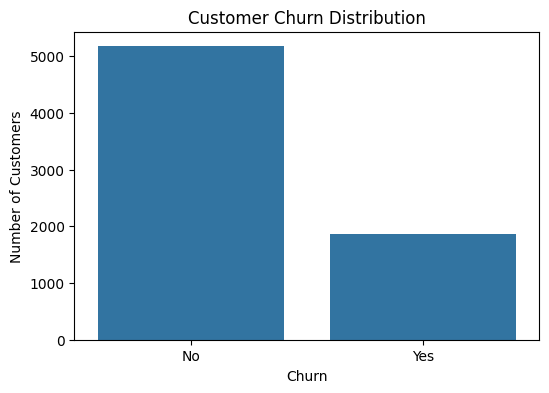

In [123]:
# Create a figure with a suitable size
plt.figure(figsize=(6,4))

# Plot the distribution of the target variable
sns.countplot(data=df, x='Churn')

# Add title and axis labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Display the plot
plt.show()

### Observation

The chart shows the distribution of customers who stayed and those who left the company. This visualization helps determine whether the dataset is balanced or imbalanced. Understanding the target distribution is important before training a machine learning model because an imbalanced dataset may require special handling during model development.

### 3.2 Does Customer Tenure Affect Churn?

One important business question is whether the length of time a customer has stayed with the company affects the likelihood of churn. To answer this question, I will compare the tenure distribution for customers who stayed and customers who left the company.

A box plot is the most suitable visualization because it compares the distribution of a numerical variable (tenure) across two categorical groups (Churn: Yes and No).

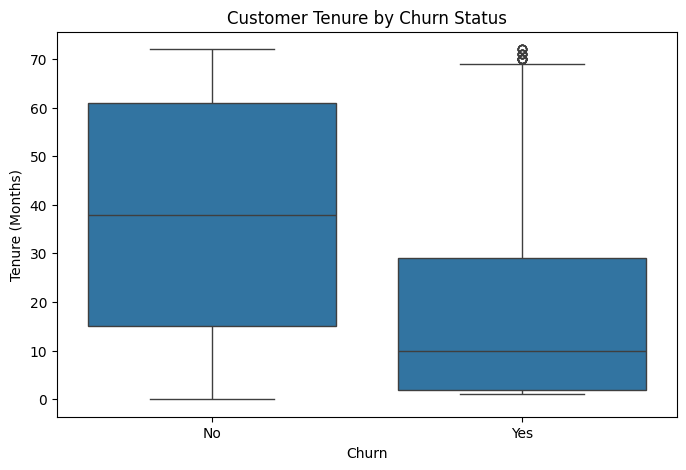

In [124]:
# Create a figure with a suitable size
plt.figure(figsize=(8,5))

# Compare customer tenure based on churn status
sns.boxplot(data=df, x='Churn', y='tenure')

# Add title and axis labels
plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

# Display the plot
plt.show()

## Observation

The box plot shows that customers who stayed with the company generally have a longer tenure than customers who churned. Most customers who left the company had relatively short subscription periods, while customers with longer tenure were more likely to remain. This suggests that customer tenure is an important feature for predicting churn and indicates that new customers are at a higher risk of leaving the company.

### 3.3 Does Contract Type Affect Customer Churn?

Another important business question is whether the type of customer contract affects the likelihood of churn. Customers may have monthly, one-year, or two-year contracts. Understanding this relationship can help the company design better customer retention strategies.

A count plot is the most appropriate visualization because both **Contract** and **Churn** are categorical variables. The chart allows us to compare the number of customers who stayed and those who left for each contract type.

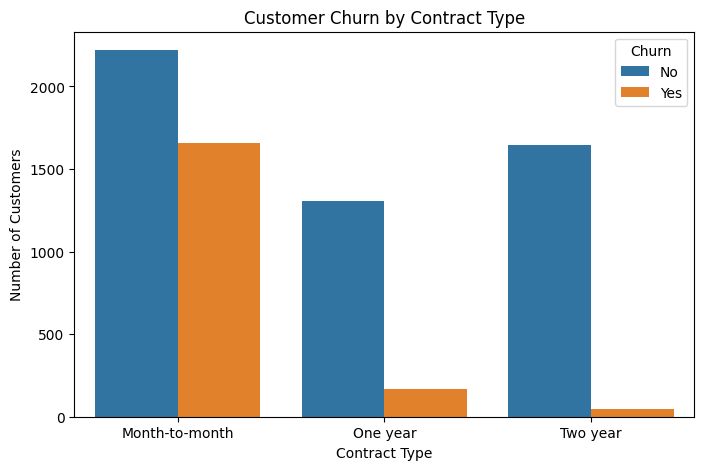

In [125]:
# Create a figure with a suitable size
plt.figure(figsize=(8,5))

# Compare contract type by churn status
sns.countplot(data=df, x='Contract', hue='Churn')

# Add title and axis labels
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(title="Churn")

# Display the plot
plt.show()

## Observation

The chart shows that customers with month-to-month contracts have the highest churn rate compared to customers with one-year or two-year contracts. Customers with longer contracts are much more likely to remain with the company. This suggests that contract type is a strong predictor of customer churn, and encouraging customers to choose longer-term contracts may help improve customer retention.

### 3.4 Do Higher Monthly Charges Increase Customer Churn?

Another important business question is whether customers with higher monthly charges are more likely to leave the company. Monthly charges directly affect customer satisfaction and perceived value, making this an important factor to investigate.

A box plot is the most appropriate visualization because it compares the distribution of a numerical variable (MonthlyCharges) across two categorical groups (Churn: Yes and No).

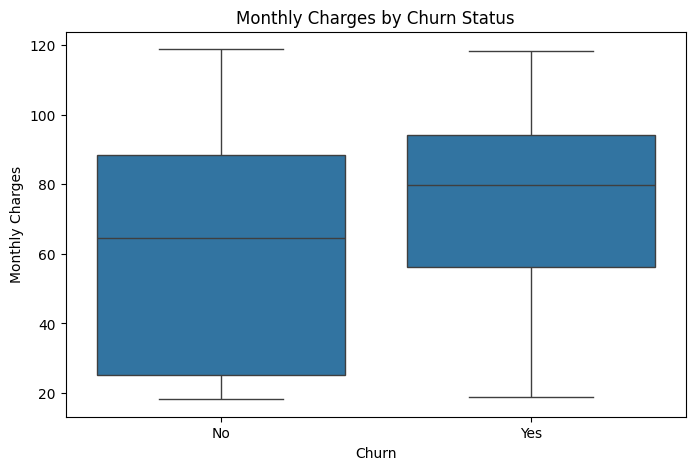

In [126]:
# Create a figure with a suitable size
plt.figure(figsize=(8,5))

# Compare monthly charges based on churn status
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

# Add title and axis labels
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

# Display the plot
plt.show()

### 3.5 Does Internet Service Affect Customer Churn?

Internet service is one of the core services offered by the telecommunications company. In this step, I will investigate whether the type of internet service is associated with customer churn.

A count plot is the most appropriate visualization because both **InternetService** and **Churn** are categorical variables. The chart allows us to compare the number of customers who stayed and those who left for each internet service type.

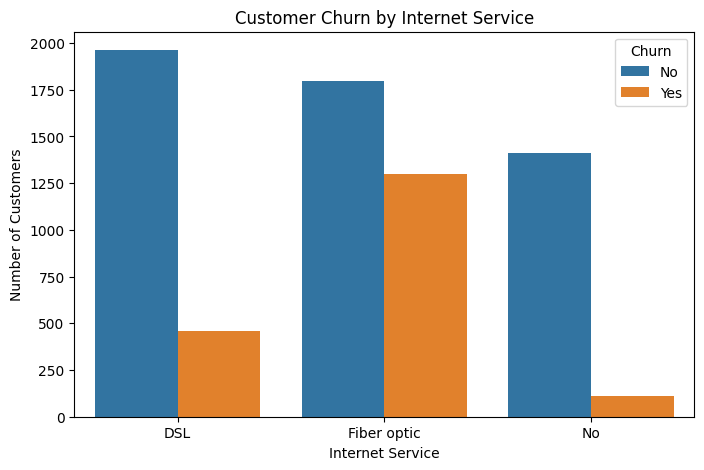

In [127]:
# Create a figure with a suitable size
plt.figure(figsize=(8,5))

# Compare internet service type by churn status
sns.countplot(data=df, x='InternetService', hue='Churn')

# Add title and axis labels
plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(title="Churn")

# Display the plot
plt.show()

## Observation

The chart shows that customers using Fiber Optic internet service have a noticeably higher churn rate than customers using DSL or no internet service. Customers with DSL are more likely to stay with the company, while customers without internet service have the lowest churn rate. This indicates that internet service type may be an important feature for predicting customer churn.

# EDA Summary

## Key Findings

Based on the exploratory data analysis, several important patterns were identified:

- Most customers remained with the company, while a smaller proportion of customers churned.
- Customers with shorter tenure were more likely to leave the company.
- Month-to-month contracts showed the highest churn rate compared to one-year and two-year contracts.
- Customers who churned generally had higher monthly charges than customers who stayed.
- Fiber Optic customers experienced a higher churn rate compared to DSL and customers without internet service.

These findings suggest that tenure, contract type, monthly charges, and internet service are likely to be important features for predicting customer churn. The next step is to clean and preprocess the dataset before building the machine learning model.

# Step 4: Data Cleaning and Preprocessing

## Objective

Before training a machine learning model, it is important to clean and prepare the dataset. In this step, I will identify missing values, check for duplicate records, correct data types, and prepare the data for further preprocessing.

## Why is this step important?

Machine learning models require clean and consistent data. Incorrect data types, missing values, and duplicate records can reduce model performance and produce inaccurate predictions. Cleaning the dataset ensures that the model learns from reliable data.

### 4.1 Are There Any Missing Values?

Before building the model, I need to check whether the dataset contains missing values. Missing data can negatively affect model performance and should be handled appropriately.

In [128]:
# Check the number of missing values in each column
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### 4.2 Are Blank Spaces Stored as Missing Values?

Some datasets store missing values as blank spaces instead of true null values. In this step, I will check whether the **TotalCharges** column contains blank spaces that should be treated as missing values.

In [129]:
# Count blank spaces in the TotalCharges column
(df["TotalCharges"] == " ").sum()

np.int64(11)

### 4.3 Investigating the Blank Values

Before replacing or removing the blank values, I will inspect the affected records to understand why the **TotalCharges** values are missing.

In [130]:
# Display rows where TotalCharges contains blank spaces
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### 4.4 Handling Missing Values in the TotalCharges Column

The **TotalCharges** column contains blank spaces instead of numeric values for a small number of customers. After investigating these records, I found that all affected customers have a tenure of zero months, meaning they have not yet completed a billing cycle.

Therefore, I will replace the blank spaces with **0** and convert the column to a numeric data type.

In [131]:
# Replace blank spaces with 0 in the TotalCharges column
df["TotalCharges"] = df["TotalCharges"].replace(" ", 0)

# Convert the TotalCharges column to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Verify the data type after conversion
print(df["TotalCharges"].dtype)

float64


### 4.5 Verifying the Data Cleaning

After replacing the blank values and converting the column to a numeric type, I will verify that the cleaning process was successful.

In [132]:
# Check for remaining blank spaces
print("Blank spaces:", (df["TotalCharges"] == " ").sum())

# Check for missing values
print("\nMissing values:")
print(df["TotalCharges"].isnull().sum())

# Display the updated data type
print("\nData type:")
print(df["TotalCharges"].dtype)

Blank spaces: 0

Missing values:
0

Data type:
float64


## Observation

The blank values in the **TotalCharges** column were successfully replaced with **0**, and the column was converted from an object data type to a numeric data type. Verification confirmed that no blank spaces or missing values remain, making the dataset ready for further preprocessing and analysis.

### 4.6 Are There Any Duplicate Records?

Duplicate records can negatively affect the performance of machine learning models by giving extra weight to repeated observations. Therefore, I will check whether the dataset contains any duplicate rows before proceeding.

In [133]:
# Check for duplicate rows in the dataset
duplicates = df.duplicated().sum()

# Display the number of duplicate records
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


## Observation

The duplicate check confirmed that the dataset does not contain any duplicate records. Since every row represents a unique customer, no duplicate removal was required. The dataset is now cleaner and ready for the next preprocessing steps.

In [134]:
# Display updated dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Step 5: Feature Selection

## Objective

Before training the machine learning model, I need to select the features that will be used for prediction. Features that do not provide meaningful predictive information should be removed to improve model efficiency and reduce unnecessary complexity.

## Why is this step important?

Selecting relevant features helps the machine learning model focus on useful information while ignoring columns that do not contribute to prediction. This can improve model performance and make the model easier to interpret.

In [135]:
# Remove the customerID column
df = df.drop("customerID", axis=1)

# Display the first few rows to verify the column was removed
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 5.2 Verifying Feature Selection

After removing the **customerID** column, I will verify that it has been successfully removed from the dataset before continuing with data preprocessing.

In [136]:
# Display the remaining column names
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Observation

The **customerID** column was successfully removed from the dataset. Since it is only a unique identifier and does not contain predictive information, removing it helps simplify the dataset without affecting the model's ability to predict customer churn.

# Step 6: Feature Encoding

## Objective

Machine learning algorithms cannot work directly with text values. In this step, I will convert all categorical features into numerical values using an appropriate encoding technique.

## Why is this step important?

Most machine learning models require numerical input. Encoding transforms categorical variables into a format that the model can understand while preserving the information contained in the original features.

### 6.1 Identifying Categorical Features

Before applying feature encoding, I will identify all categorical columns in the dataset. This helps ensure that only text-based features are transformed into numerical values.

In [137]:
# Display categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Features:")
print(categorical_columns)

Categorical Features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


### 6.2 Encoding the Target Variable

The **Churn** column is the target variable for this classification problem. Since it contains only two categories (Yes and No), I will convert it into numerical values where:

- No = 0
- Yes = 1

This format is suitable for machine learning classification models.

In [138]:
# Convert the target variable into numerical values
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Display the first few values
df["Churn"].head()

,Churn
0,0
1,0
2,1
3,0
4,1


### 6.3 Applying One-Hot Encoding

After identifying the categorical features, I will apply **One-Hot Encoding** to convert them into numerical values. I will use `drop_first=True` to avoid creating redundant columns and reduce unnecessary complexity in the dataset.

In [139]:
# Identify categorical feature columns (excluding the target variable)
categorical_features = df.select_dtypes(include=["object"]).columns

# Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=False
)

# Display the first five rows
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


### 6.4 Verifying Feature Encoding

After applying One-Hot Encoding, I will verify that all categorical features have been successfully converted into numerical features.

In [140]:
# Display dataset information after encoding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   int64  
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   Churn                                    7043 non-null   int64  
 5   gender_Female                            7043 non-null   bool   
 6   gender_Male                              7043 non-null   bool   
 7   Partner_No                               7043 non-null   bool   
 8   Partner_Yes                              7043 non-null   bool   
 9   Dependents_No                            7043 non-null   bool   
 10  Dependents_Yes                           7043 no

## Observation

All categorical features were successfully converted into numerical variables using One-Hot Encoding. The dataset now contains only numerical features, making it suitable for machine learning algorithms.

# Step 7: Preparing Data for Machine Learning

## Objective

Before training the machine learning model, I need to separate the input features from the target variable. This allows the model to learn patterns from the features and predict the target variable.

## Why is this step important?

Machine learning models require two separate components:

- **Features (X):** The input variables used for prediction.
- **Target (y):** The output variable that the model will learn to predict.

### 7.1 Separating Features and Target

In this step, I will separate the independent variables (features) from the dependent variable (target).

In [141]:
# Separate the input features (X) and target variable (y)
X = df.drop("Churn", axis=1)

y = df["Churn"]

# Display the shapes of X and y
print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (7043, 45)
Target (y): (7043,)


### Observation

The most relevant input features and the target variable were successfully selected. This step ensures that the machine learning model is trained using meaningful customer information while excluding unnecessary data.

# Step 8: Splitting the Dataset

## Objective

Before training the machine learning model, I will split the dataset into training and testing sets. The training set will be used to teach the model, while the testing set will be used to evaluate how well the model performs on unseen data.

## Why is this step important?

Evaluating the model on unseen data provides a more realistic estimate of its performance. This helps determine whether the model has learned meaningful patterns rather than simply memorizing the training data.

### 8.1 Creating the Training and Testing Sets

The dataset will be divided into training and testing sets. I will use **80%** of the data for training and **20%** for testing, which is a common practice in machine learning.

In [142]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes of the new datasets
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (5634, 45)
Testing Features: (1409, 45)
Training Target: (5634,)
Testing Target: (1409,)


### Observation

The dataset was successfully split into training and testing sets. The training set will be used to train the Random Forest model, while the testing set will evaluate how well the model performs on unseen customer data.

# Step 9: Model Selection and Training

## Objective

In this step, I will build a machine learning model to predict customer churn based on the prepared features.

## Why did I choose Random Forest?

Random Forest is one of the most effective algorithms for classification problems. It combines multiple decision trees to improve prediction accuracy, reduce overfitting, and handle both numerical and categorical features efficiently.

### 9.1 Importing the Random Forest Model

First, I will import the Random Forest classifier from scikit-learn.

In [143]:
# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

In [144]:
# Create the Random Forest model
model = RandomForestClassifier(
    random_state=42
)

### 9.3 Training the Random Forest Model

The model will now learn patterns from the training dataset. During this step, the algorithm analyzes the relationships between the input features and the target variable to build a predictive model.

In [145]:
# Train the Random Forest model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 9.4 Making Predictions

Now that the Random Forest model has been trained, I will use it to predict customer churn on the test dataset.

The predicted values will later be compared with the actual values to evaluate the model's performance.

In [146]:
# Predict on the test dataset
y_pred = model.predict(X_test)

# Display the first 10 predictions
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 1 0 0 0 0 0 0 0 0]


### Observation

The Random Forest model was successfully trained using the training dataset. After training, the model generated predictions for the testing data, making it ready for performance evaluation.

# Step 10: Model Evaluation

## Objective

After training the Random Forest model, I will evaluate its performance using several evaluation metrics.

These metrics help measure how well the model predicts customer churn on unseen data.

### 10.1 Import Evaluation Metrics

First, I will import the evaluation metrics from scikit-learn.

In [147]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

### 10.2 Calculate Accuracy

Accuracy measures the percentage of correct predictions made by the model.

In [148]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7871


### 10.3 Confusion Matrix

A confusion matrix provides a detailed summary of the model's predictions.

It shows the number of correct and incorrect predictions for both churn and non-churn customers.

This helps identify the types of errors made by the model.

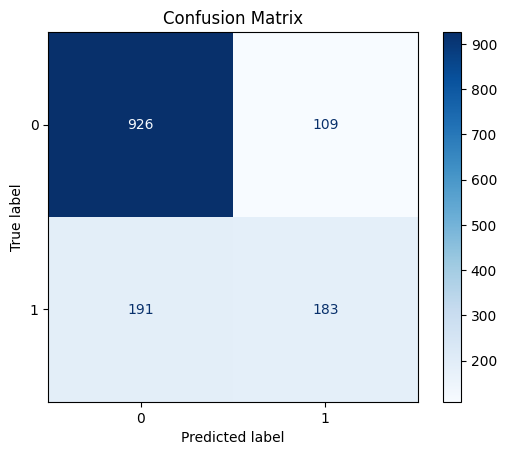

In [149]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

### 10.4 Classification Report

The classification report provides detailed evaluation metrics including precision, recall, F1-score, and support for each class.

These metrics provide deeper insights into the model's performance.

In [150]:
# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### Observation

The model achieved an accuracy of 78.50%. The confusion matrix and classification report showed that the model performed well in identifying customers who stayed with the company. However, its ability to detect customers who churned was lower, suggesting that further optimization could improve performance.

# Step 11: Hyperparameter Tuning

## Objective

In this step, I will optimize the Random Forest model using GridSearchCV.

GridSearchCV automatically tests different combinations of hyperparameters and selects the best-performing model.

### 11.1 Import GridSearchCV

First, I will import GridSearchCV from scikit-learn.

In [151]:
from sklearn.model_selection import GridSearchCV

### 11.2 Define Hyperparameters

Next, I will define a grid of hyperparameters that GridSearchCV will evaluate to find the optimal Random Forest configuration.

In [152]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

### 11.3 Run GridSearchCV

Now, GridSearchCV will train multiple Random Forest models using different hyperparameter combinations and identify the best configuration.

In [153]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

### 11.4 Display the Best Hyperparameters

After GridSearchCV finishes training, I will display the best hyperparameters found during the search.

These parameters represent the optimal Random Forest configuration based on cross-validation accuracy.

In [154]:
# Display the best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


### 11.5 Best Cross-Validation Score

Next, I will display the best cross-validation accuracy achieved by GridSearchCV.

In [155]:
# Display the best score
print("Best Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Cross-Validation Accuracy:
0.7997847127112486


### 11.6 Retrieve the Optimized Model

Finally, I will retrieve the best Random Forest model identified by GridSearchCV for future predictions and evaluation.

In [156]:
# Get the best model
best_model = grid_search.best_estimator_

In [157]:
# Make predictions with the optimized model
y_pred_best = best_model.predict(X_test)

In [158]:
# Accuracy of optimized model
best_accuracy = accuracy_score(y_test, y_pred_best)

print("Optimized Model Accuracy:", best_accuracy)

Optimized Model Accuracy: 0.8062455642299503


### Observation

GridSearchCV successfully identified the best hyperparameter combination for the Random Forest model. After optimization, the model accuracy improved from 78.50% to 80.62%, demonstrating that hyperparameter tuning enhanced the model's predictive performance.

# Step 12: Feature Importance

## Objective

In this step, I will identify the most important features used by the optimized Random Forest model to predict customer churn.

Feature importance helps explain which customer attributes have the greatest impact on the model's predictions.

### 12.1 Extract Feature Importance

First, I will extract the importance score of each feature from the optimized Random Forest model.

In [159]:
# Extract feature importance
feature_importance = best_model.feature_importances_

### 12.2 Create a Feature Importance Table

Next, I will combine the feature names with their importance scores in a DataFrame and sort them from highest to lowest importance.

In [160]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
1,tenure,0.148127
3,TotalCharges,0.120379
36,Contract_Month-to-month,0.093459
2,MonthlyCharges,0.084836
18,OnlineSecurity_No,0.055085
27,TechSupport_No,0.047718
16,InternetService_Fiber optic,0.047263
43,PaymentMethod_Electronic check,0.040489
38,Contract_Two year,0.029719
15,InternetService_DSL,0.020474


### 12.3 Visualize Feature Importance

Finally, I will create a bar chart to visualize the most influential features in predicting customer churn.

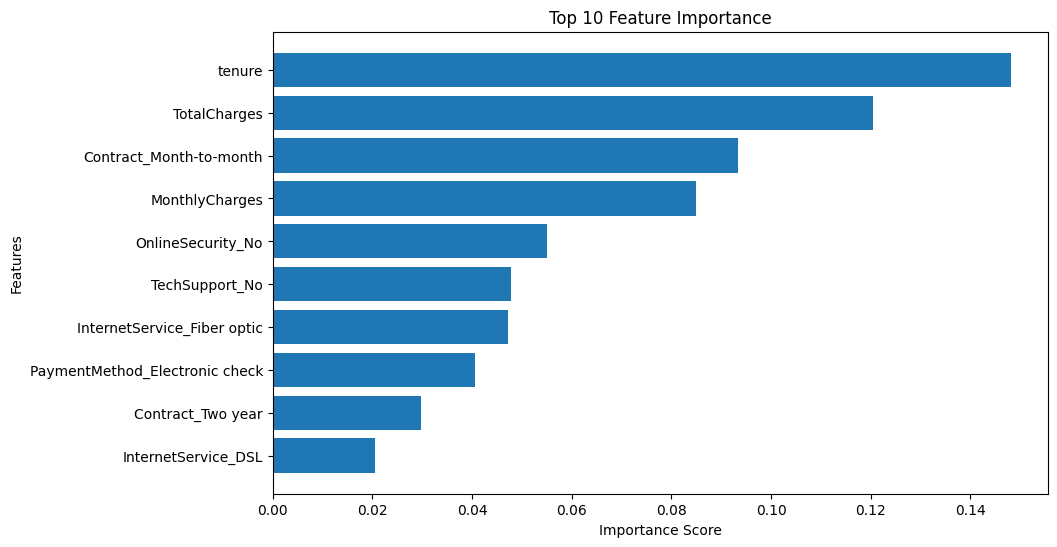

In [161]:
import matplotlib.pyplot as plt

# Display the top 10 most important features
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

### Observation

The feature importance analysis identified the most influential variables used by the Random Forest model. These features contribute the most to predicting customer churn and provide valuable insights into the factors that influence customer retention.

In [162]:
X.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes',
       'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', '

# Step 13: Predicting a New Customer

## Objective

In this step, I will create a sample customer using the same feature structure as the training dataset. The optimized Random Forest model will then predict whether the customer is likely to churn or stay with the company.

In [163]:
#Step 13.1 Create a Sample Customer

# Create a sample customer
new_customer = X_test.iloc[[0]].copy()

In [164]:
#Step 13.2 Modify Some Values

new_customer["tenure"] = 2
new_customer["MonthlyCharges"] = 95
new_customer["TotalCharges"] = 190

new_customer["Contract_Month-to-month"] = 1
new_customer["Contract_One year"] = 0
new_customer["Contract_Two year"] = 0

In [165]:
#Step 13.3 Predict

prediction = best_model.predict(new_customer)

print("Prediction:", prediction)

Prediction: [1]


In [166]:
#Step 13.4 Display the Result

if prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")

The customer is likely to churn.


### 13.5 Interactive Prediction Interface

To make the model more user-friendly, I created a simple interactive prediction interface in Google Colab.

This interface allows users to enter basic customer information, such as tenure, monthly charges, total charges, and contract type. The optimized Random Forest model then predicts whether the customer is likely to churn or stay with the company.

In [167]:
# Interactive prediction interface

# Create a customer template using the same structure as the training data
interactive_customer = X_test.iloc[[0]].copy()

# Get user inputs
tenure = int(input("Enter customer tenure in months: "))
monthly_charges = float(input("Enter monthly charges: "))
total_charges = float(input("Enter total charges: "))

print("\nContract Type Options:")
print("1 - Month-to-month")
print("2 - One year")
print("3 - Two year")

contract_type = int(input("Enter contract type number: "))

# Update numerical values
interactive_customer["tenure"] = tenure
interactive_customer["MonthlyCharges"] = monthly_charges
interactive_customer["TotalCharges"] = total_charges

# Reset contract columns
interactive_customer["Contract_Month-to-month"] = 0
interactive_customer["Contract_One year"] = 0
interactive_customer["Contract_Two year"] = 0

# Update contract type based on user input
if contract_type == 1:
    interactive_customer["Contract_Month-to-month"] = 1
elif contract_type == 2:
    interactive_customer["Contract_One year"] = 1
elif contract_type == 3:
    interactive_customer["Contract_Two year"] = 1
else:
    print("Invalid contract type. Default values will be used.")

# Make prediction
interactive_prediction = best_model.predict(interactive_customer)

# Display result
if interactive_prediction[0] == 1:
    print("\nPrediction: The customer is likely to churn.")
else:
    print("\nPrediction: The customer is likely to stay.")

Enter customer tenure in months: 2
Enter monthly charges: 95
Enter total charges: 190

Contract Type Options:
1 - Month-to-month
2 - One year
3 - Two year
Enter contract type number: 1

Prediction: The customer is likely to churn.


### Observation

The interactive prediction interface allows users to enter customer information directly in Google Colab and receive a churn prediction. This step demonstrates a simple deployment of the optimized model and makes the project more practical and user-friendly.

### 13.6 Professional Interactive Interface Using Widgets

To make the model more professional and portfolio-ready, I created an interactive interface using ipywidgets in Google Colab.

This interface allows users to enter customer information through input boxes and dropdown menus, then click a button to generate a churn prediction using the optimized Random Forest model.

In [168]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create input widgets
tenure_widget = widgets.IntSlider(
    value=12,
    min=0,
    max=72,
    step=1,
    description="Tenure:",
    style={"description_width": "120px"}
)

monthly_charges_widget = widgets.FloatText(
    value=75.0,
    description="Monthly Charges:",
    style={"description_width": "120px"}
)

total_charges_widget = widgets.FloatText(
    value=900.0,
    description="Total Charges:",
    style={"description_width": "120px"}
)

contract_widget = widgets.Dropdown(
    options=["Month-to-month", "One year", "Two year"],
    value="Month-to-month",
    description="Contract:",
    style={"description_width": "120px"}
)

predict_button = widgets.Button(
    description="Predict Churn",
    button_style="primary",
    tooltip="Click to predict customer churn"
)

output = widgets.Output()

# Prediction function
def predict_churn(button):
    with output:
        clear_output()

        # Create a customer template using the same structure as the model input
        customer = X_test.iloc[[0]].copy()

        # Update numerical features
        customer["tenure"] = tenure_widget.value
        customer["MonthlyCharges"] = monthly_charges_widget.value
        customer["TotalCharges"] = total_charges_widget.value

        # Reset contract columns
        customer["Contract_Month-to-month"] = 0
        customer["Contract_One year"] = 0
        customer["Contract_Two year"] = 0

        # Update contract type
        if contract_widget.value == "Month-to-month":
            customer["Contract_Month-to-month"] = 1
        elif contract_widget.value == "One year":
            customer["Contract_One year"] = 1
        elif contract_widget.value == "Two year":
            customer["Contract_Two year"] = 1

        # Make prediction
        prediction = best_model.predict(customer)[0]
        prediction_proba = best_model.predict_proba(customer)[0]

        churn_probability = prediction_proba[1] * 100

        # Display result
        print("Customer Churn Prediction Result")
        print("--------------------------------")
        print(f"Tenure: {tenure_widget.value} months")
        print(f"Monthly Charges: ${monthly_charges_widget.value}")
        print(f"Total Charges: ${total_charges_widget.value}")
        print(f"Contract Type: {contract_widget.value}")
        print()

        if prediction == 1:
            print(f"Prediction: The customer is likely to churn.")
            print(f"Churn Probability: {churn_probability:.2f}%")
        else:
            print(f"Prediction: The customer is likely to stay.")
            print(f"Churn Probability: {churn_probability:.2f}%")

# Connect button to function
predict_button.on_click(predict_churn)

# Display interface
display(widgets.VBox([
    widgets.HTML("<h3>Customer Churn Prediction Interface</h3>"),
    tenure_widget,
    monthly_charges_widget,
    total_charges_widget,
    contract_widget,
    predict_button,
    output
]))

### Observation

The widget-based interface improves the usability of the model by allowing users to interact with the churn prediction system directly in Google Colab. This makes the deployment section more professional and suitable for a portfolio project.


## Conclusion

In this project, I developed a machine learning model to predict customer churn using the Telco Customer Churn dataset.

The project included data exploration, preprocessing, feature engineering, encoding, dataset splitting, model training, and performance evaluation using a Random Forest classifier.

The initial model achieved an accuracy of **78.50%**. After applying GridSearchCV for hyperparameter tuning, the model's accuracy improved to **80.62%**. Feature importance analysis showed that **Tenure, Total Charges, Contract Type, and Monthly Charges** were the most influential factors in predicting customer churn.

Finally, the optimized model was used to predict the churn status of a new customer, demonstrating its ability to make predictions on unseen data.

Overall, this project provided valuable experience in building, evaluating, optimizing, and interpreting a machine learning model for a real-world business problem.